In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [9]:
df = pd.read_csv('/home/starkiwj/LLM/venv/FinalProject/merged_dataset.csv')
df.head(3)

,Unnamed: 0,cbsa,Date,AQI,Category
0,5127386,"Aberdeen, SD",1985-04-28,19,Good
1,5127387,"Aberdeen, SD",1985-05-04,64,Moderate
2,5127388,"Aberdeen, SD",1985-05-07,35,Good


In [10]:
# Select the city to analyze
# You can change this variable to analyze any city in the dataset
selected_city = "Columbus, OH"

# Show available cities in the dataset
print("Available cities:")
print(df["cbsa"].unique())

Available cities:
<ArrowStringArray>
[                     'Aberdeen, SD',                      'Aberdeen, WA',
                           'Ada, OK',                      'Adjuntas, PR',
                        'Adrian, MI',                     'Aguadilla, PR',
                         'Akron, OH',                    'Alamogordo, NM',
                        'Albany, GA',                        'Albany, NY',
 ...
                      'Woodward, OK',                     'Worcester, MA',
                  'Worcester, MA-CT',                        'Yakima, WA',
                          'York, PA',                  'York-Hanover, PA',
                    'Youngstown, OH', 'Youngstown-Warren-Boardman, OH-PA',
                     'Yuba City, CA',                          'Yuma, AZ']
Length: 849, dtype: str


In [11]:
df["Category"] = (
    df["Category"]
    .str.strip()
    .str.lower()
)

In [12]:
city = df[df["cbsa"] == selected_city].copy()

city["date"] = pd.to_datetime(city["Date"])

city = city.sort_values("date")

city["year"] = city["date"].dt.year
city["month"] = city["date"].dt.month
city["dayofyear"] = city["date"].dt.dayofyear

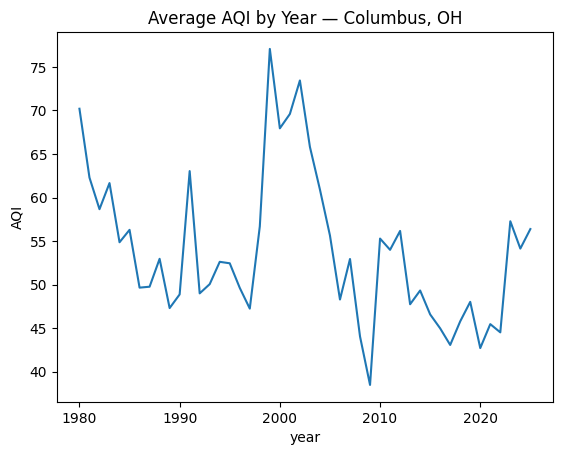

In [13]:
yearly = city.groupby("year")["AQI"].mean()

plt.figure()
yearly.plot()
plt.title(f"Average AQI by Year — {selected_city}")
plt.ylabel("AQI")
plt.show()

In [14]:
year_df = yearly.reset_index()

X = year_df[["year"]]
y = year_df["AQI"]

model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])

Slope: -0.23293814747402883


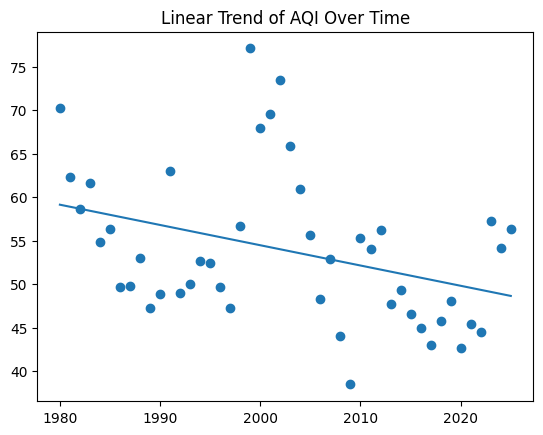

In [15]:
plt.figure()
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.title("Linear Trend of AQI Over Time")
plt.show()

This clearly shows that AQI has been decreasing over time

# Classification problem based on data

In [16]:
city["prev_AQI"] = city["AQI"].shift(1)

city = city.dropna()


In [17]:
city["Category"] = city["Category"].astype("category")
city["cat_code"] = city["Category"].cat.codes
city["Category"].unique()

['moderate', 'unhealthy for sensitive groups', 'good', 'unhealthy', 'very unhealthy']
Categories (5, str): ['good', 'moderate', 'unhealthy', 'unhealthy for sensitive groups', 'very unhealthy']

In [18]:
X = city[["year","month","dayofyear","prev_AQI"]]
y = city["cat_code"]


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)


In [20]:
tree = DecisionTreeClassifier(max_depth=6)
tree.fit(X_train, y_train)

pred = tree.predict(X_test)

# define category order explicitly
labels = ['good',
          'moderate',
          'unhealthy',
          'unhealthy for sensitive groups',
          'very unhealthy']

cat_names = list(city["Category"].cat.categories)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred,
                            target_names=cat_names))

Accuracy: 0.6609055501460565
                                precision    recall  f1-score   support

                          good       0.75      0.80      0.78      2310
                      moderate       0.53      0.58      0.56      1450
                     unhealthy       0.36      0.05      0.09        76
unhealthy for sensitive groups       0.32      0.04      0.07       263
                very unhealthy       0.00      0.00      0.00         9

                      accuracy                           0.66      4108
                     macro avg       0.39      0.30      0.30      4108
                  weighted avg       0.64      0.66      0.64      4108



/home/starkiwj/LLM/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/starkiwj/LLM/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/starkiwj/LLM/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

Support reveals most days are in the good/moderate category. Recall reveals that the classifier misses a significant amount of unhealthy and unhelathy for sensitive group days. This would imply that days that are not good/moderate are difficult to predict using temporal features alone. Precision also reveals the model is not necessarily great at prediting unhealthy days, or even to some degree moderate days. The low f1-score for unhealty/very unhealthy days reveals that those types of days are rare or irregular. Very unhealthy days and unhealthy for sensitive group days are the most difficult to model. Rarer categories are the most difficult to predict because there is the least amount of training data on them. 

In [21]:
pd.Series(tree.feature_importances_, index=X.columns)\
    .sort_values(ascending=False)

prev_AQI     0.819879
year         0.133401
dayofyear    0.046719
month        0.000000
dtype: float64

The temporal feature which best explains AQI is the previous days AQI. There is also a strong prescence of long term historical trends. 

In [22]:
city["Category"].value_counts(normalize=True)

Category
good                              0.567194
moderate                          0.348144
unhealthy for sensitive groups    0.063968
unhealthy                         0.018807
very unhealthy                    0.001887
Name: proportion, dtype: float64

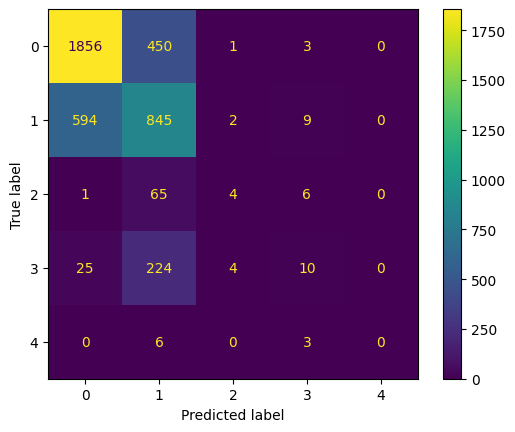

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, pred)

# K-Means clustering for pattern discovery

In [24]:
cluster_data = city[["AQI","month"]]

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(cluster_data)

city["cluster"] = labels


OpenBLAS warning: precompiled NUM_THREADS exceeded, adding auxiliary array for thread metadata.
To avoid this warning, please rebuild your copy of OpenBLAS with a larger NUM_THREADS setting
or set the environment variable OPENBLAS_NUM_THREADS to 64 or lower


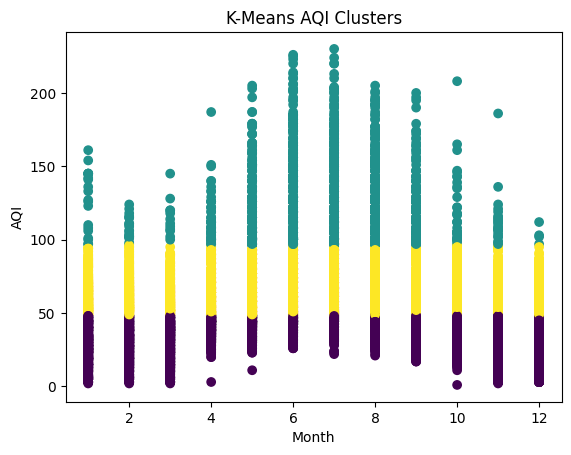

In [25]:
plt.figure()
plt.scatter(city["month"], city["AQI"], c=city["cluster"])
plt.xlabel("Month")
plt.ylabel("AQI")
plt.title("K-Means AQI Clusters")
plt.show()


In [26]:
city.groupby("cluster")["AQI"].mean()

cluster
0     33.527425
1    128.472170
2     63.863890
Name: AQI, dtype: float64

Cluster 0 represents clean, low AQI days. Cluster 1 represents unhealthy, high AQI days. Cluster 2 represents moderate, medium AQI days.

In [27]:
city.groupby("cluster")["month"].mean()

cluster
0    6.479560
1    6.733583
2    6.398163
Name: month, dtype: float64

In [28]:
city.groupby("cluster")["year"].mean()

cluster
0    2002.009275
1    1996.765478
2    2003.491145
Name: year, dtype: float64

In [29]:
city.groupby("cluster")["Category"].value_counts(normalize=True)

cluster  Category                      
0        good                              1.000000
         moderate                          0.000000
         unhealthy for sensitive groups    0.000000
         unhealthy                         0.000000
         very unhealthy                    0.000000
1        unhealthy for sensitive groups    0.657286
         unhealthy                         0.193246
         moderate                          0.130081
         very unhealthy                    0.019387
         good                              0.000000
2        moderate                          0.903903
         good                              0.096097
         unhealthy for sensitive groups    0.000000
         unhealthy                         0.000000
         very unhealthy                    0.000000
Name: proportion, dtype: float64

In [30]:
city.groupby("cluster")["year"].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,8733.0,2002.009275,13.100270,1980.0,1990.0,2002.0,2014.0,2025.0
1,1599.0,1996.765478,10.484897,1980.0,1989.0,1997.0,2004.0,2025.0
2,6098.0,2003.491145,13.282265,1980.0,1993.0,2004.0,2014.0,2025.0


In [31]:
# city.groupby(["year","cluster"]).size().unstack(fill_value=0)

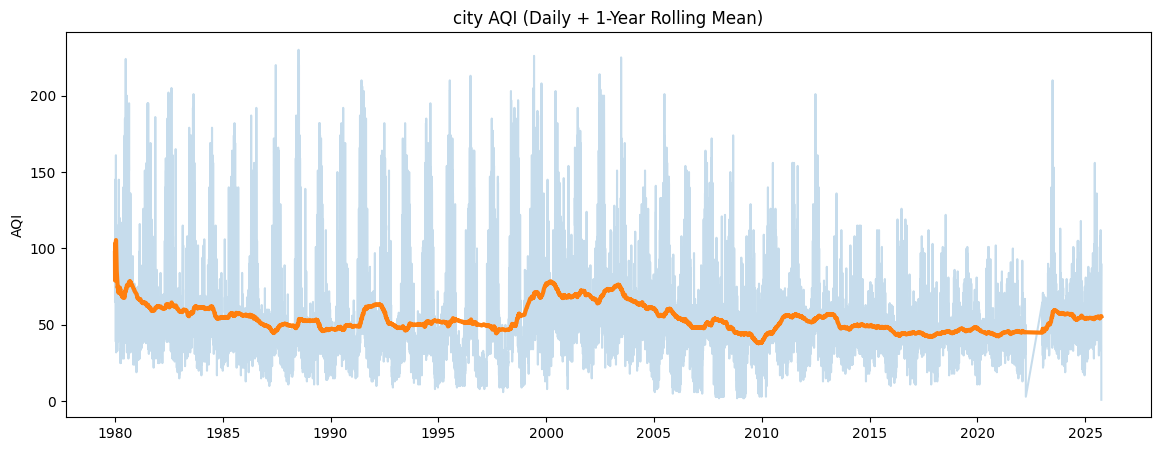

In [32]:
plt.figure(figsize=(14,5))

plt.plot(city["date"], city["AQI"], alpha=0.25)

rolling = city.set_index("date")["AQI"].rolling("365D").mean()

plt.plot(rolling.index, rolling, linewidth=3)

plt.title("city AQI (Daily + 1-Year Rolling Mean)")
plt.ylabel("AQI")
plt.show()


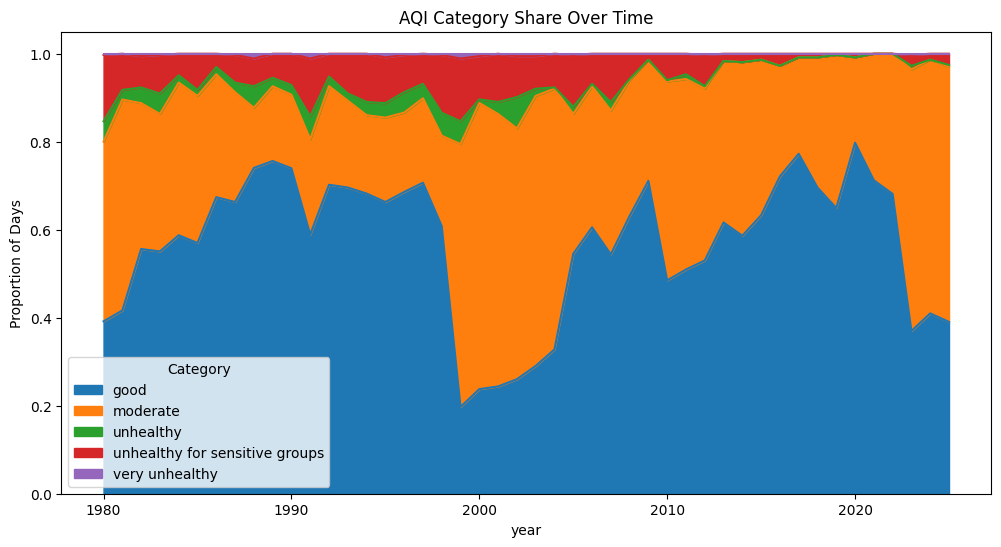

In [33]:
cat_year = (
    city
    .groupby(["year","Category"])
    .size()
    .unstack(fill_value=0)
)

cat_year_pct = cat_year.div(cat_year.sum(axis=1), axis=0)

cat_year_pct.plot.area(figsize=(12,6))

plt.title("AQI Category Share Over Time")
plt.ylabel("Proportion of Days")
plt.show()

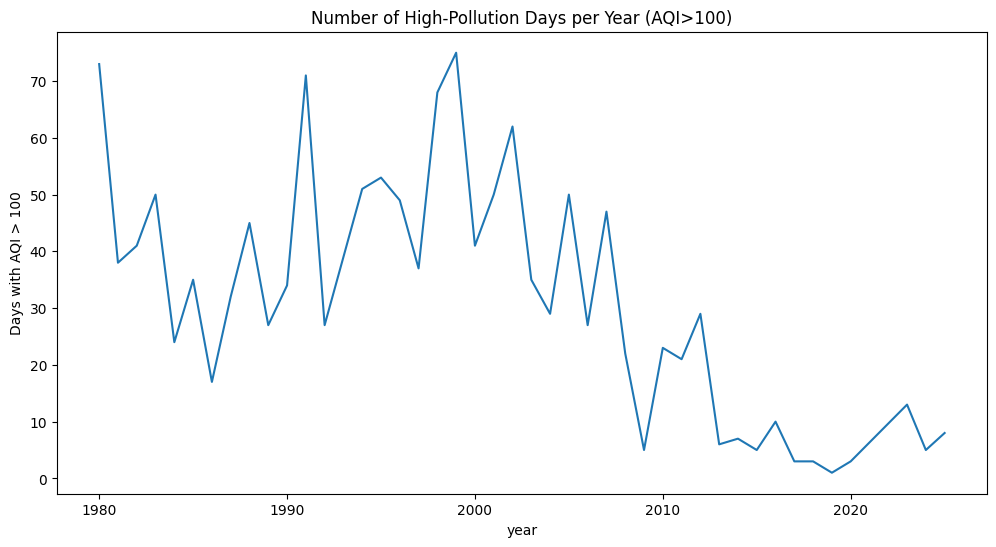

In [34]:
bad = city[city["AQI"] > 100]

bad.groupby("year").size().plot(figsize=(12,6))
plt.title("Number of High-Pollution Days per Year (AQI>100)")
plt.ylabel("Days with AQI > 100")
plt.show()


<Figure size 1200x600 with 0 Axes>

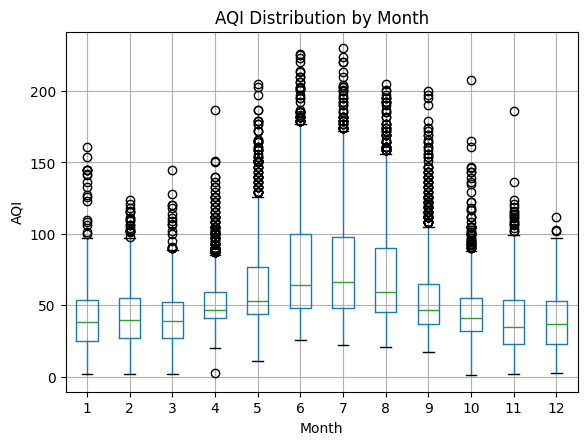

In [35]:
plt.figure(figsize=(12,6))

city.boxplot(column="AQI", by="month")

plt.title("AQI Distribution by Month")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("AQI")
plt.show()


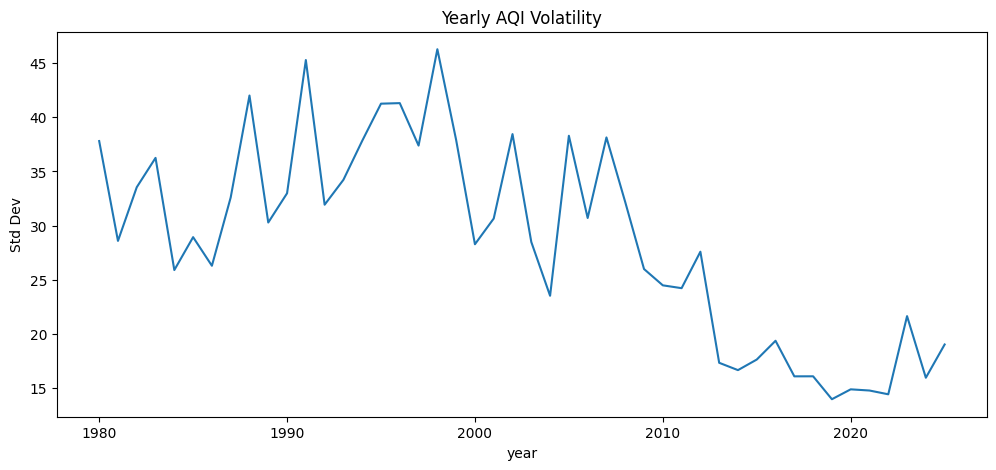

In [36]:
vol = city.groupby("year")["AQI"].std()

vol.plot(figsize=(12,5))

plt.title("Yearly AQI Volatility")
plt.ylabel("Std Dev")
plt.show()


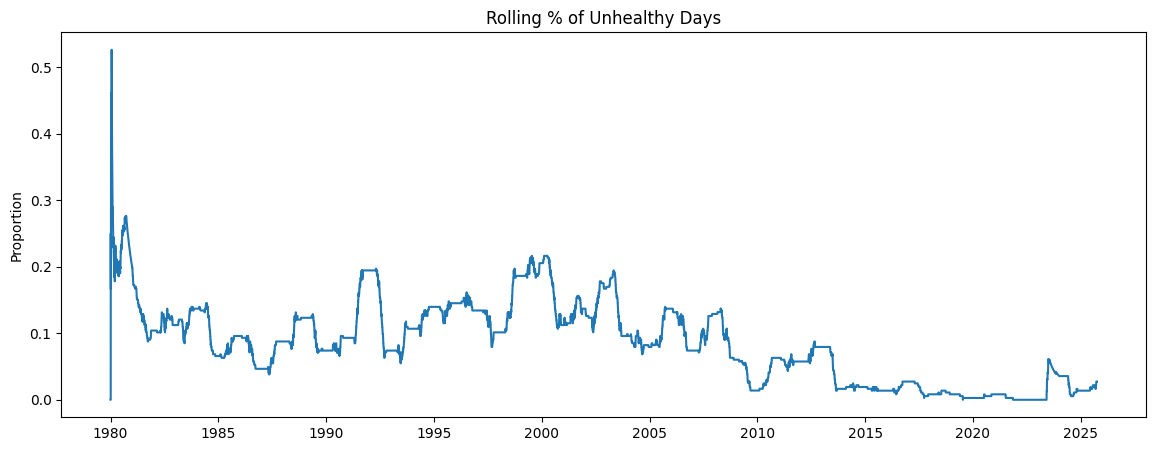

In [37]:
city["bad"] = city["Category"].isin(
    ["unhealthy","unhealthy for sensitive groups","very unhealthy"]
)

bad_rate = (
    city.set_index("date")["bad"]
    .rolling("365D")
    .mean()
)

plt.figure(figsize=(14,5))
plt.plot(bad_rate.index, bad_rate)

plt.title("Rolling % of Unhealthy Days")
plt.ylabel("Proportion")
plt.show()


# More visuals for presentation

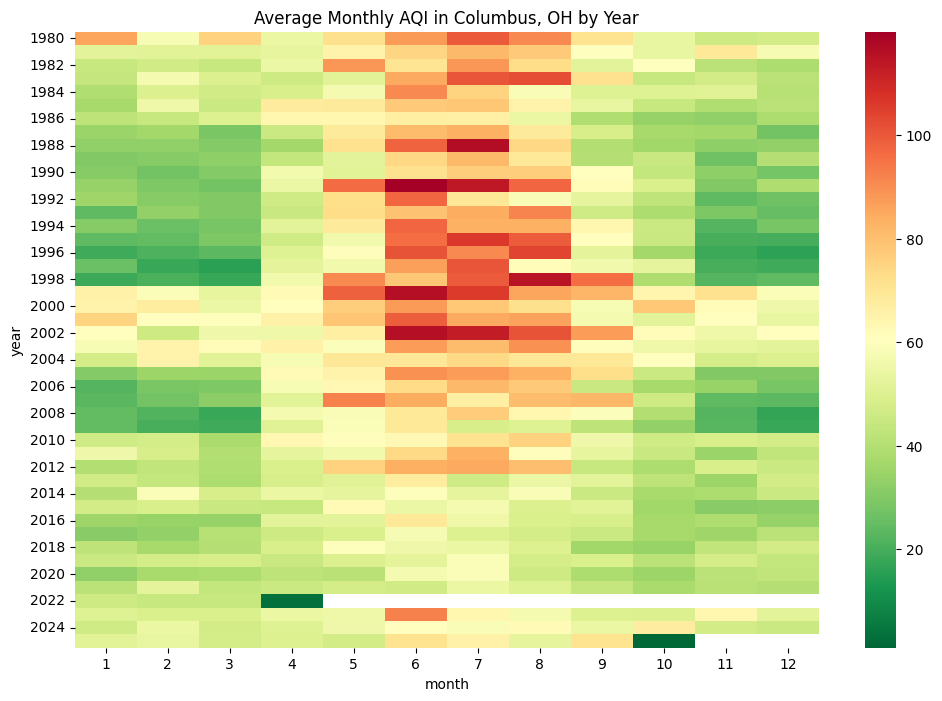

In [38]:
pivot = city.pivot_table(
    values="AQI",
    index="year",
    columns="month",
    aggfunc="mean"
)

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap="RdYlGn_r")
plt.title(f"Average Monthly AQI in {selected_city} by Year")
plt.show()

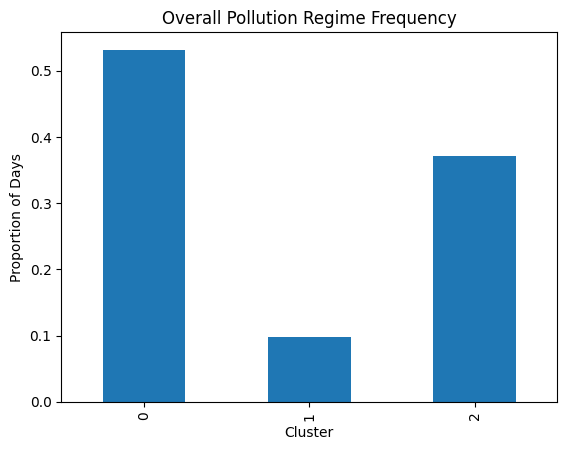

In [39]:
city["cluster"].value_counts(normalize=True).sort_index().plot(kind="bar")

plt.title("Overall Pollution Regime Frequency")
plt.ylabel("Proportion of Days")
plt.xlabel("Cluster")
plt.show()

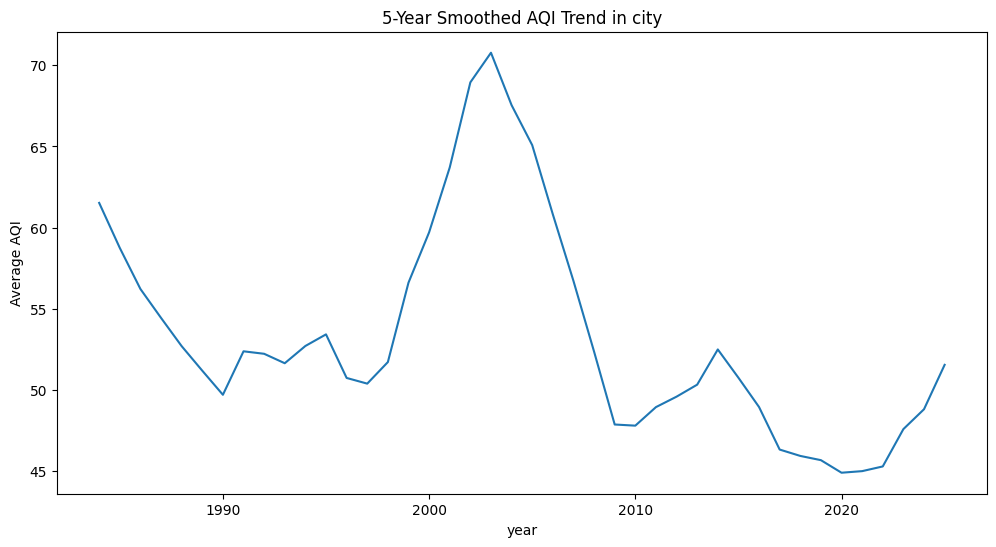

In [40]:
yearly = city.groupby("year")["AQI"].mean()

yearly.rolling(5).mean().plot(figsize=(12,6))

plt.title("5-Year Smoothed AQI Trend in city")
plt.ylabel("Average AQI")
plt.show()


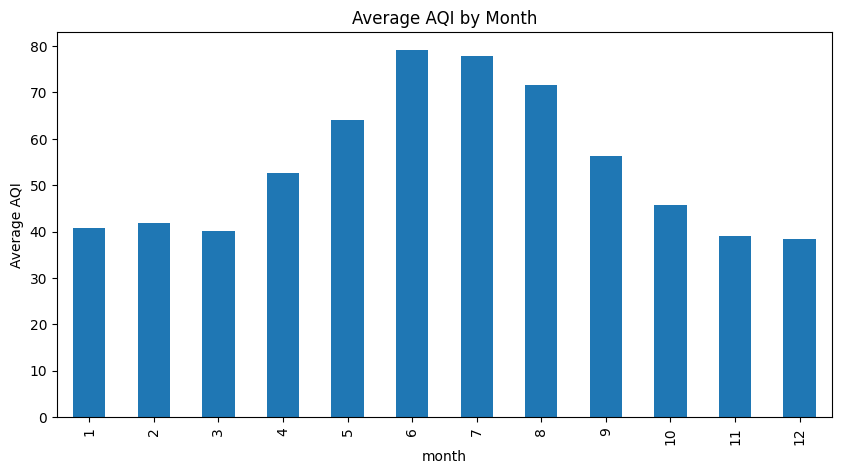

In [41]:
monthly = city.groupby("month")["AQI"].mean()

monthly.plot(kind="bar", figsize=(10,5))
plt.title("Average AQI by Month")
plt.ylabel("Average AQI")
plt.show()

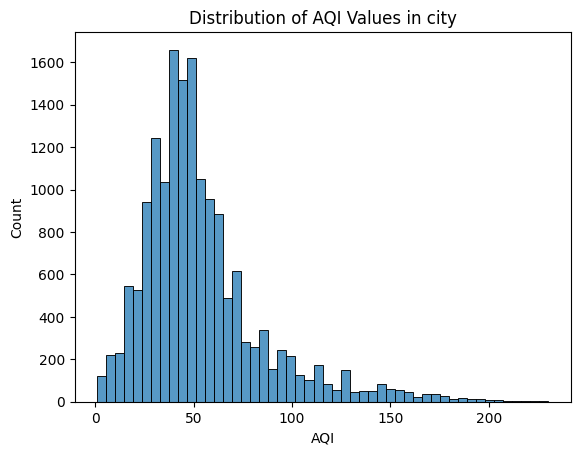

In [42]:
sns.histplot(city["AQI"], bins=50)
plt.title("Distribution of AQI Values in city")
plt.show()


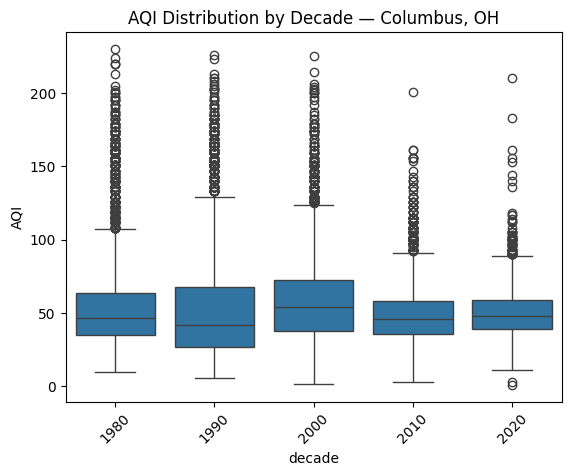

In [43]:
city["decade"] = (city["year"]//10)*10

sns.boxplot(data=city, x="decade", y="AQI")
plt.xticks(rotation=45)
plt.title(f"AQI Distribution by Decade — {selected_city}")
plt.show()